# Project Introduction
This project builds an ANN.

## Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import confusion_matrix,classification_report
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Dense,Dropout


## Load Dataset

In [21]:
df=pd.read_csv('fashion_1M.csv')
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,brand,price_INR,discount_pct,effective_price_INR,rating,num_reviews,in_stock
0,1,Men,Apparel,Bottomwear,Track Pants,Red,Summer,2014,Formal,Wildcraft,5398,50,2699,3.6,7345,Yes
1,2,Men,Personal Care,Skin Care,Moisturiser,Silver,Summer,2011,Casual,Zara,2072,15,1761,4.1,5282,No
2,3,Men,Footwear,Shoes,Flats,Green,Summer,2022,Sports,Bata,3867,50,1934,4.2,8058,Yes
3,4,Women,Accessories,Jewellery,Ring,Brown,Summer,2016,Sports,Wrangler,4706,20,3765,4.8,10278,Yes
4,5,Boys,Apparel,Loungewear,Bathrobes,Black,Summer,2024,Casual,W,7489,0,7489,3.6,13243,Yes


## Dataset Overview

In [22]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.info())
print(df.describe(include='all'))

   id gender masterCategory subCategory  articleType baseColour  season  year  \
0   1    Men        Apparel  Bottomwear  Track Pants        Red  Summer  2014   
1   2    Men  Personal Care   Skin Care  Moisturiser     Silver  Summer  2011   
2   3    Men       Footwear       Shoes        Flats      Green  Summer  2022   
3   4  Women    Accessories   Jewellery         Ring      Brown  Summer  2016   
4   5   Boys        Apparel  Loungewear    Bathrobes      Black  Summer  2024   

    usage      brand  price_INR  discount_pct  effective_price_INR  rating  \
0  Formal  Wildcraft       5398            50                 2699     3.6   
1  Casual       Zara       2072            15                 1761     4.1   
2  Sports       Bata       3867            50                 1934     4.2   
3  Sports   Wrangler       4706            20                 3765     4.8   
4  Casual          W       7489             0                 7489     3.6   

   num_reviews in_stock  
0         7345    

## Data Cleaning

In [23]:
df=df.drop_duplicates()
print(df.isnull().sum())
df=df.dropna()

id                     0
gender                 0
masterCategory         0
subCategory            0
articleType            0
baseColour             0
season                 0
year                   0
usage                  0
brand                  0
price_INR              0
discount_pct           0
effective_price_INR    0
rating                 0
num_reviews            0
in_stock               0
dtype: int64


## EDA

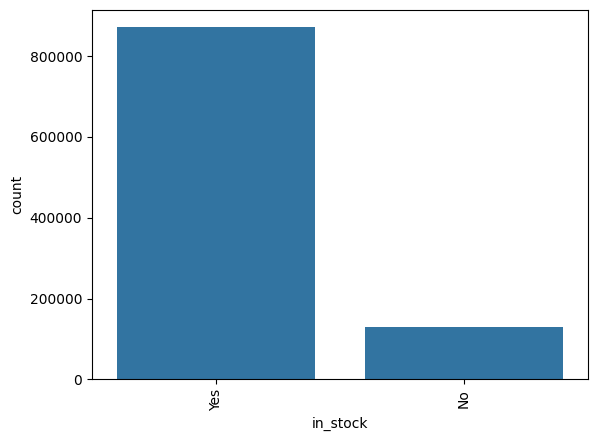

In [24]:
sns.countplot(x=df.iloc[:,-1]);plt.xticks(rotation=90);plt.show()

## Feature Engineering

In [25]:
target=df.columns[-1]
X=df.drop(columns=[target]).copy()
y=df[target].copy()
for c in X.select_dtypes(include='object').columns:
 X[c]=LabelEncoder().fit_transform(X[c].astype(str))
if y.dtype=='object':
 y=LabelEncoder().fit_transform(y.astype(str))

## Train-Test Split

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Feature Scaling

In [27]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

## Build ANN

In [28]:
model=Sequential([Dense(128,activation='relu',input_shape=(X_train.shape[1],)),Dropout(0.3),Dense(64,activation='relu'),Dense(len(np.unique(y)),activation='softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile

In [29]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

## Train

In [30]:
history=model.fit(X_train,y_train,batch_size=32,validation_split=0.2)

20000/20000 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - accuracy: 0.8700 - loss: 0.3884 - val_accuracy: 0.8701 - val_loss: 0.3863


## Evaluate

In [31]:
loss,acc=model.evaluate(X_test,y_test)
print(loss,acc)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8706 - loss: 0.3857
0.3856583535671234 0.8705549836158752


## Confusion Matrix

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 991us/step


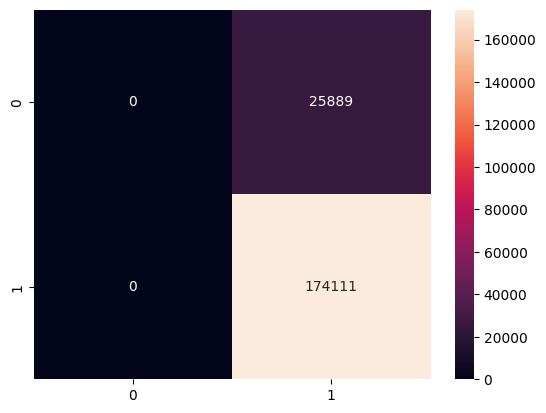

In [32]:
pred=model.predict(X_test).argmax(axis=1)
cm=confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True,fmt='d');plt.show()

## Classification Report

In [33]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     25889
           1       0.87      1.00      0.93    174111

    accuracy                           0.87    200000
   macro avg       0.44      0.50      0.47    200000
weighted avg       0.76      0.87      0.81    200000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Accuracy & Loss Graphs

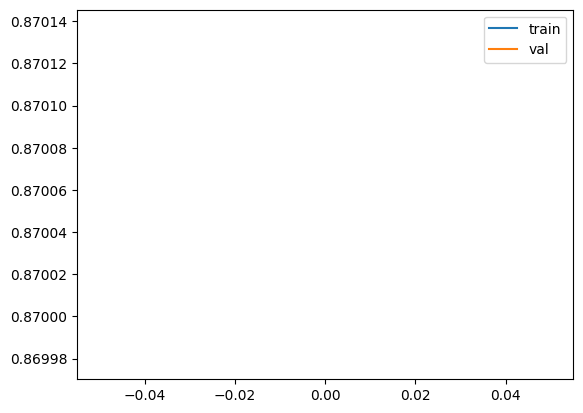

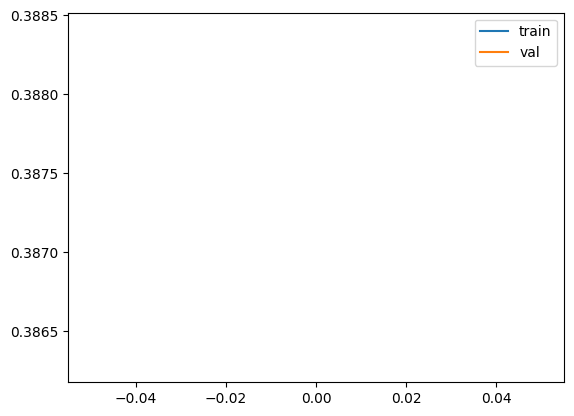

In [34]:
plt.plot(history.history['accuracy']);plt.plot(history.history['val_accuracy']);plt.legend(['train','val']);plt.show()
plt.plot(history.history['loss']);plt.plot(history.history['val_loss']);plt.legend(['train','val']);plt.show()

## Predictions

In [35]:
print(pred[:10])

[1 1 1 1 1 1 1 1 1 1]


## Save Model

In [36]:
model.save('fashion_ann_model.h5')

## Load Saved Model

In [37]:
loaded=load_model('fashion_ann_model.h5')
loaded.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,436 (40.77 KB)

 Trainable params: 10,434 (40.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Final Conclusion

In [38]:
print('Model pipeline completed successfully.')

Model pipeline completed successfully.
